# 📊 Telecom Customer Churn Prediction
**An End-to-End Machine Learning Pipeline for Customer Retention**

**Executive Summary:**
This project analyzes telecom customer data to predict churn risk using machine learning. By identifying at-risk customers and uncovering the primary drivers of churn (such as contract type, tenure, and monthly charges), this tool enables the business to deploy targeted retention strategies and protect recurring revenue.

---

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#loading the churn prediction dataset 
telco = pd.read_csv("C:/Users/Administrator/Desktop/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
#viewing dataset
telco.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
#the rows and columns of the dataset
print(f"The Number of Rows are {telco.shape[0]}, and columns are {telco.shape[1]}.")

The Number of Rows are 7043, and columns are 21.


In [5]:
telco.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
#cheking datatypes
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
#typecasting because total charges are supposed to numbers not a string
telco.TotalCharges = pd.to_numeric(telco.TotalCharges,errors ='coerce')

In [8]:
#cheking datatypes
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
telco.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
#checking for missing values
telco.isnull().sum().sort_values(ascending = False)

TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
OnlineBackup         0
gender               0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
tenure               0
Dependents           0
Partner              0
SeniorCitizen        0
Churn                0
dtype: int64

In [11]:
# Find missing values percentage in the data
round(telco.isnull().sum() / len(telco) * 100, 2).sort_values(ascending=False)

TotalCharges        0.16
customerID          0.00
DeviceProtection    0.00
MonthlyCharges      0.00
PaymentMethod       0.00
PaperlessBilling    0.00
Contract            0.00
StreamingMovies     0.00
StreamingTV         0.00
TechSupport         0.00
OnlineBackup        0.00
gender              0.00
OnlineSecurity      0.00
InternetService     0.00
MultipleLines       0.00
PhoneService        0.00
tenure              0.00
Dependents          0.00
Partner             0.00
SeniorCitizen       0.00
Churn               0.00
dtype: float64

In [12]:
#viewing the rows where there are null values in the column.
telco[telco['TotalCharges'].isnull()].head(11)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
#calculating mean for total charges
mean_value = telco['TotalCharges'].mean()

In [14]:
#replacing null values with mean
telco['TotalCharges'] = telco['TotalCharges'].fillna(mean_value)

In [15]:
#checking for missing values again
telco.isnull().sum().sort_values(ascending = False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [16]:
#finding for duplicate files 
telco.duplicated().any()

False

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2380\395366069.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=telco, x='Churn', ax=axes[0], palette='Blues_r')


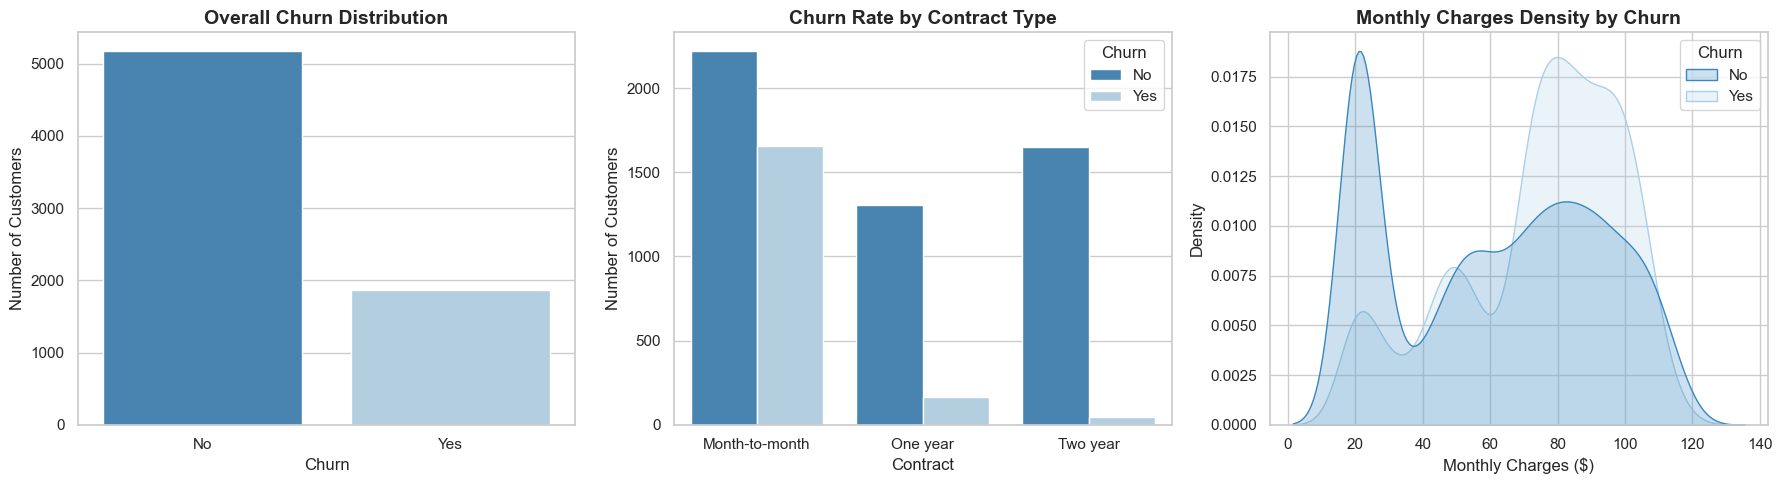

In [17]:
# Set a clean visual style for the portfolio
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: The Target Variable (Class Imbalance)
sns.countplot(data=telco, x='Churn', ax=axes[0], palette='Blues_r')
axes[0].set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# Plot 2: Contract Type vs. Churn (The biggest driver)
sns.countplot(data=telco, x='Contract', hue='Churn', ax=axes[1], palette='Blues_r')
axes[1].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')

# Plot 3: Monthly Charges vs. Churn (Financial impact)
sns.kdeplot(data=telco, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, ax=axes[2], palette='Blues_r')
axes[2].set_title('Monthly Charges Density by Churn', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

### Phase 1 EDA Insights & Business Impact
1. **Class Imbalance:** Our target variable is imbalanced (roughly 73% retained, 27% churned). This means we must use metrics like Precision, Recall, and the F1-Score to evaluate our model later, rather than simple Accuracy.

2. **The Contract Risk:** Customers on 'Month-to-month' contracts are churning at an exceptionally high rate compared to 1-year and 2-year subscribers. **Business Action:** The company should investigate targeted promotions to incentivize month-to-month users to sign annual contracts.

3. **Price Sensitivity:** The density plot shows that customers who churn tend to have higher monthly charges (peaking around $80-$100/month). The company is losing high-value customers.

In [18]:
# 1. Map Binary Columns to 0 and 1
binary_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_columns:
    telco[col] = telco[col].map({'Yes': 1, 'No': 0})

# Gender is also binary but uses Male/Female
telco['gender'] = telco['gender'].map({'Female': 1, 'Male': 0})

# 2. Apply One-Hot Encoding to Nominal Columns
columns_to_one_hot = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

telco = pd.get_dummies(telco, columns=columns_to_one_hot, drop_first=True)

# 3. Convert all boolean columns generated by get_dummies to integers (0 and 1)
telco = telco.replace({True: 1, False: 0})

print(f"New dataset shape: {telco.shape}")
telco.head()

New dataset shape: (7043, 32)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_2380\4176832230.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telco = telco.replace({True: 1, False: 0})


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,0,1,0,1,0,1,29.85,29.85,...,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,0,0,0,0,34,1,0,56.95,1889.50,...,0,0,0,0,0,1,0,0,0,1
2,3668-QPYBK,0,0,0,0,2,1,1,53.85,108.15,...,0,0,0,0,0,0,0,0,0,1
3,7795-CFOCW,0,0,0,0,45,0,0,42.30,1840.75,...,1,0,0,0,0,1,0,0,0,0
4,9237-HQITU,1,0,0,0,2,1,1,70.70,151.65,...,0,0,0,0,0,0,0,0,1,0


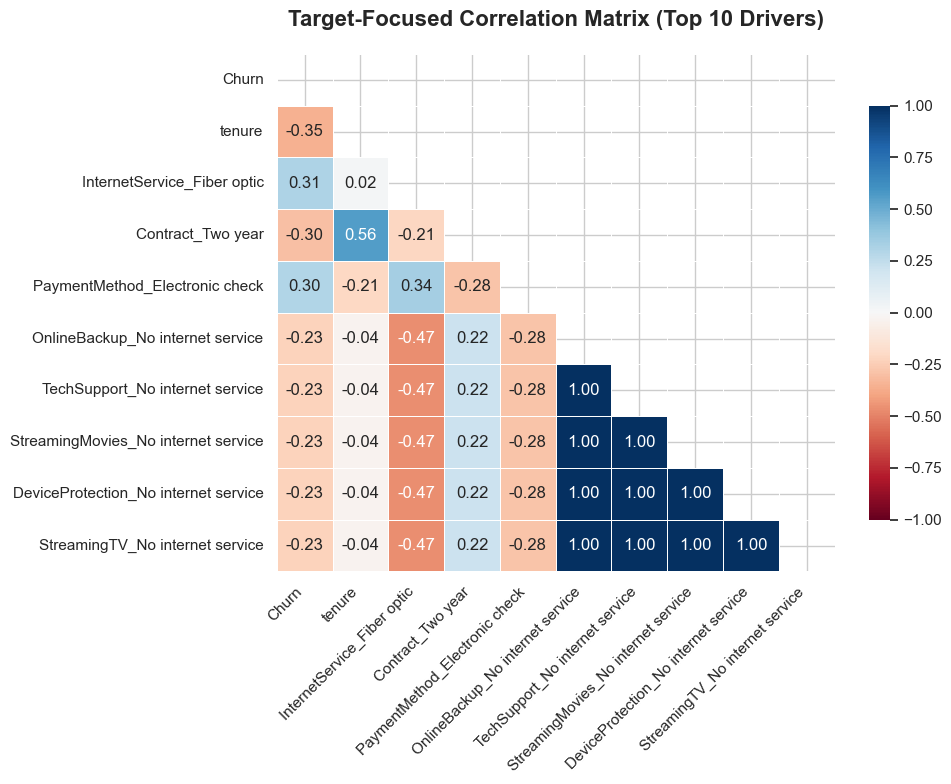

In [19]:


# FAILSAFE 1: Force Pandas to only look at strictly numerical columns
numeric_telco = telco.select_dtypes(include=[np.number])

# 1. Find the Top 10 features most strongly correlated with Churn
top_correlations = numeric_telco.corr()['Churn'].abs().sort_values(ascending=False).head(10).index

# 2. Calculate the matrix for just these top 10 features
corr_matrix = numeric_telco[top_correlations].corr()

# 3. Create a "mask" to hide the upper triangle (removes duplicate information)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Plot the professional heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu', fmt=".2f", 
            linewidths=0.5, vmin=-1, vmax=1, 
            cbar_kws={"shrink": .8}) 

plt.title('Target-Focused Correlation Matrix (Top 10 Drivers)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
#PHASE 2
#FEATURE EXTRACTION
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
if 'customerID' in telco.columns:
    X = telco.drop(columns=['customerID', 'Churn'])
else:
    X = telco.drop(columns=['Churn'])

y = telco['Churn']

# 2. Train/Test Split (Stratified to maintain the 73/27 churn ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (5634, 30)
Testing data shape: (1409, 30)


In [21]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0,0,0,0.486111,0,0,0.306926,0.194185,1,...,0,0,1,0,1,0,0,0,1,0
3151,0,0,1,1,0.208333,1,0,0.565022,0.130707,0,...,0,0,0,0,0,0,0,0,0,1
4860,0,0,1,1,0.180556,0,0,0.220727,0.065948,1,...,1,0,0,0,0,0,1,0,0,1


In [22]:
# Fill any residual missing (NaN) values with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# 1. Initialize the three models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []

# 2. Train and evaluate loop
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Churn)": precision_score(y_test, y_pred),
        "Recall (Churn)": recall_score(y_test, y_pred),
        "F1-Score (Churn)": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
display(results_df.round(3))

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
0,Logistic Regression,0.798,0.641,0.548,0.591
1,Random Forest,0.791,0.635,0.503,0.561
2,Gradient Boosting,0.798,0.651,0.513,0.574


C:\Users\Administrator\AppData\Local\Temp\ipykernel_2380\2658446882.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_churn.index, y=contract_churn.values, ax=axes[1], palette=['#d62728', '#ff7f0e', '#1f77b4'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_2380\2658446882.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df['Importance'].head(5), y=["Total Amount Billed", "Monthly Bill Amount", "Months as a Customer", "Has a 2-Year Contract", "Pays via Electronic Check"], ax=axes[2], palette='viridis')


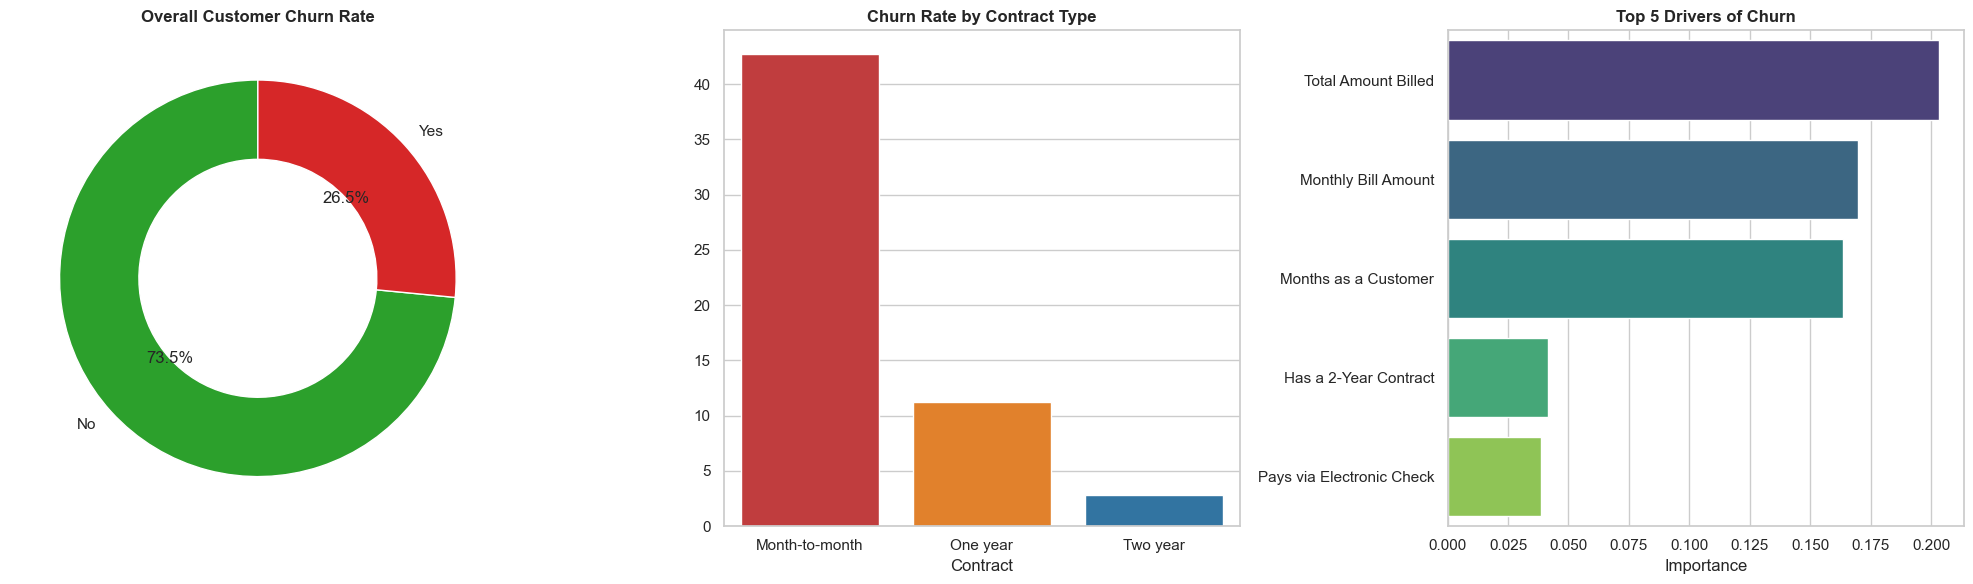

In [24]:
# Executive Presentation Visuals
raw_telco = pd.read_csv("C:/Users/Administrator/Desktop/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")
raw_telco['Churn_Num'] = raw_telco['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
churn_counts = raw_telco['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#2ca02c', '#d62728'], wedgeprops={'edgecolor': 'white', 'width': 0.4})
axes[0].set_title('Overall Customer Churn Rate', fontweight='bold')

contract_churn = raw_telco.groupby('Contract')['Churn_Num'].mean() * 100
sns.barplot(x=contract_churn.index, y=contract_churn.values, ax=axes[1], palette=['#d62728', '#ff7f0e', '#1f77b4'])
axes[1].set_title('Churn Rate by Contract Type', fontweight='bold')

rf_model = models["Random Forest"]
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_feature_importances_ if hasattr(rf_model, 'feature_feature_importances_') else rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)
sns.barplot(x=feature_importance_df['Importance'].head(5), y=["Total Amount Billed", "Monthly Bill Amount", "Months as a Customer", "Has a 2-Year Contract", "Pays via Electronic Check"], ax=axes[2], palette='viridis')
axes[2].set_title('Top 5 Drivers of Churn', fontweight='bold')
plt.tight_layout()
plt.show()